# Análisis en profundidad de los "outliers" de mid-range

## Introducción

En el Notebook 1 identificamos los jugadores más eficientes desde mid-range en la temporada 2024-25:

- **Kevin Durant** — 53.1% FG desde mid-range
- **Nikola Jokic** — 51.7% FG desde mid-range
- **Devin Booker** — 51.7% FG desde mid-range
- **Mikal Bridges** — 50.7% FG desde mid-range

(FG: Field Goal. Es decir, cualquier canasta anotada, excluyendo tiro libre)

## Objetivo del segundo Notebook

Responder dos preguntas:

1. **¿Desde dónde tiran?** — Mapas de calor de sus lanzamientos
2. **¿Son buenos en todo?** — Perfil completo de eficiencia por zona para determinar si son jugadores sobresalientes en todo o simplemente especialistas en mid-range

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd

In [2]:
# Como vamos a usar esto varias veces con cada jugador, es bueno sacar una función
# Es un "get" casero de los lanzamientos de un jugador

def get_shots_player(player_id, season):
    data = shotchartdetail.ShotChartDetail(
        team_id=0,
        player_id=player_id,
        context_measure_simple="FGA",
        season_nullable=season,
        season_type_all_star="Regular Season"
    ).get_data_frames()[0]
    data["SEASON"] = season
    return data

In [3]:
# Echando un vistazo a los jugadores en el otro notebook, sacamos sus IDs,
# Aunque también lo podemos hacer de la siguiente manera, ya que estamos:

nombres = ["Kevin Durant", "Nikola Jokić", "Devin Booker", "Mikal Bridges"]

lista = []
for nombre in nombres:
    resultado = players.find_players_by_full_name(nombre)[0] # Me vuelve loco este cero. Explico abajo por qué.
    lista.append(resultado)

# Sobre el 0: find_players_by_full_name devuelve UNA LISTA. Y meter una lista dentro de otra lista hace que después pandas no sepa hacer el DataFrame
# Pero si escoges el primer elemento, lo que te devuelve es un diccionario. Ahí pandas ya sabe lo que hacer.
# Desconozco el motivo, pero funciona.

df_players_estudio = pd.DataFrame(lista)
df_players_estudio[["id", "full_name"]]

,id,full_name
0,201142,Kevin Durant
1,203999,Nikola Jokić
2,1626164,Devin Booker
3,1628969,Mikal Bridges


In [4]:
# Almacenamos las ids y luego las pasamos a un diccionario:
durant_id = 201142
jokic_id = 203999
booker_id = 1626164
bridges_id = 1628969

jugadores = {
    "Kevin Durant": durant_id,
    "Nikola Jokić": jokic_id,
    "Devin Booker": booker_id,
    "Mikal Bridges": bridges_id
}

# El motivo por el que lo hago así es por si tengo que volver a usar esas ids
# No podemos ver el futuro, pero sí nos podemos anticipar y evitar trabajo duro

In [5]:
 # Diccionario vacío, almacenamos ahí todos los players en un bucle usando la función que hemos creado
shots_por_jugador = {}

for nombre, player_id in jugadores.items():
    shots_por_jugador[nombre] = get_shots_player(player_id, "2024-25")

#Creamos el dataframe con el que vamos a estudiar casi todo
df = pd.concat(shots_por_jugador.values(), ignore_index=True)

df["PLAYER_NAME"].value_counts()

PLAYER_NAME
Devin Booker     1420
Nikola Jokić     1364
Mikal Bridges    1183
Kevin Durant     1124
Name: count, dtype: int64

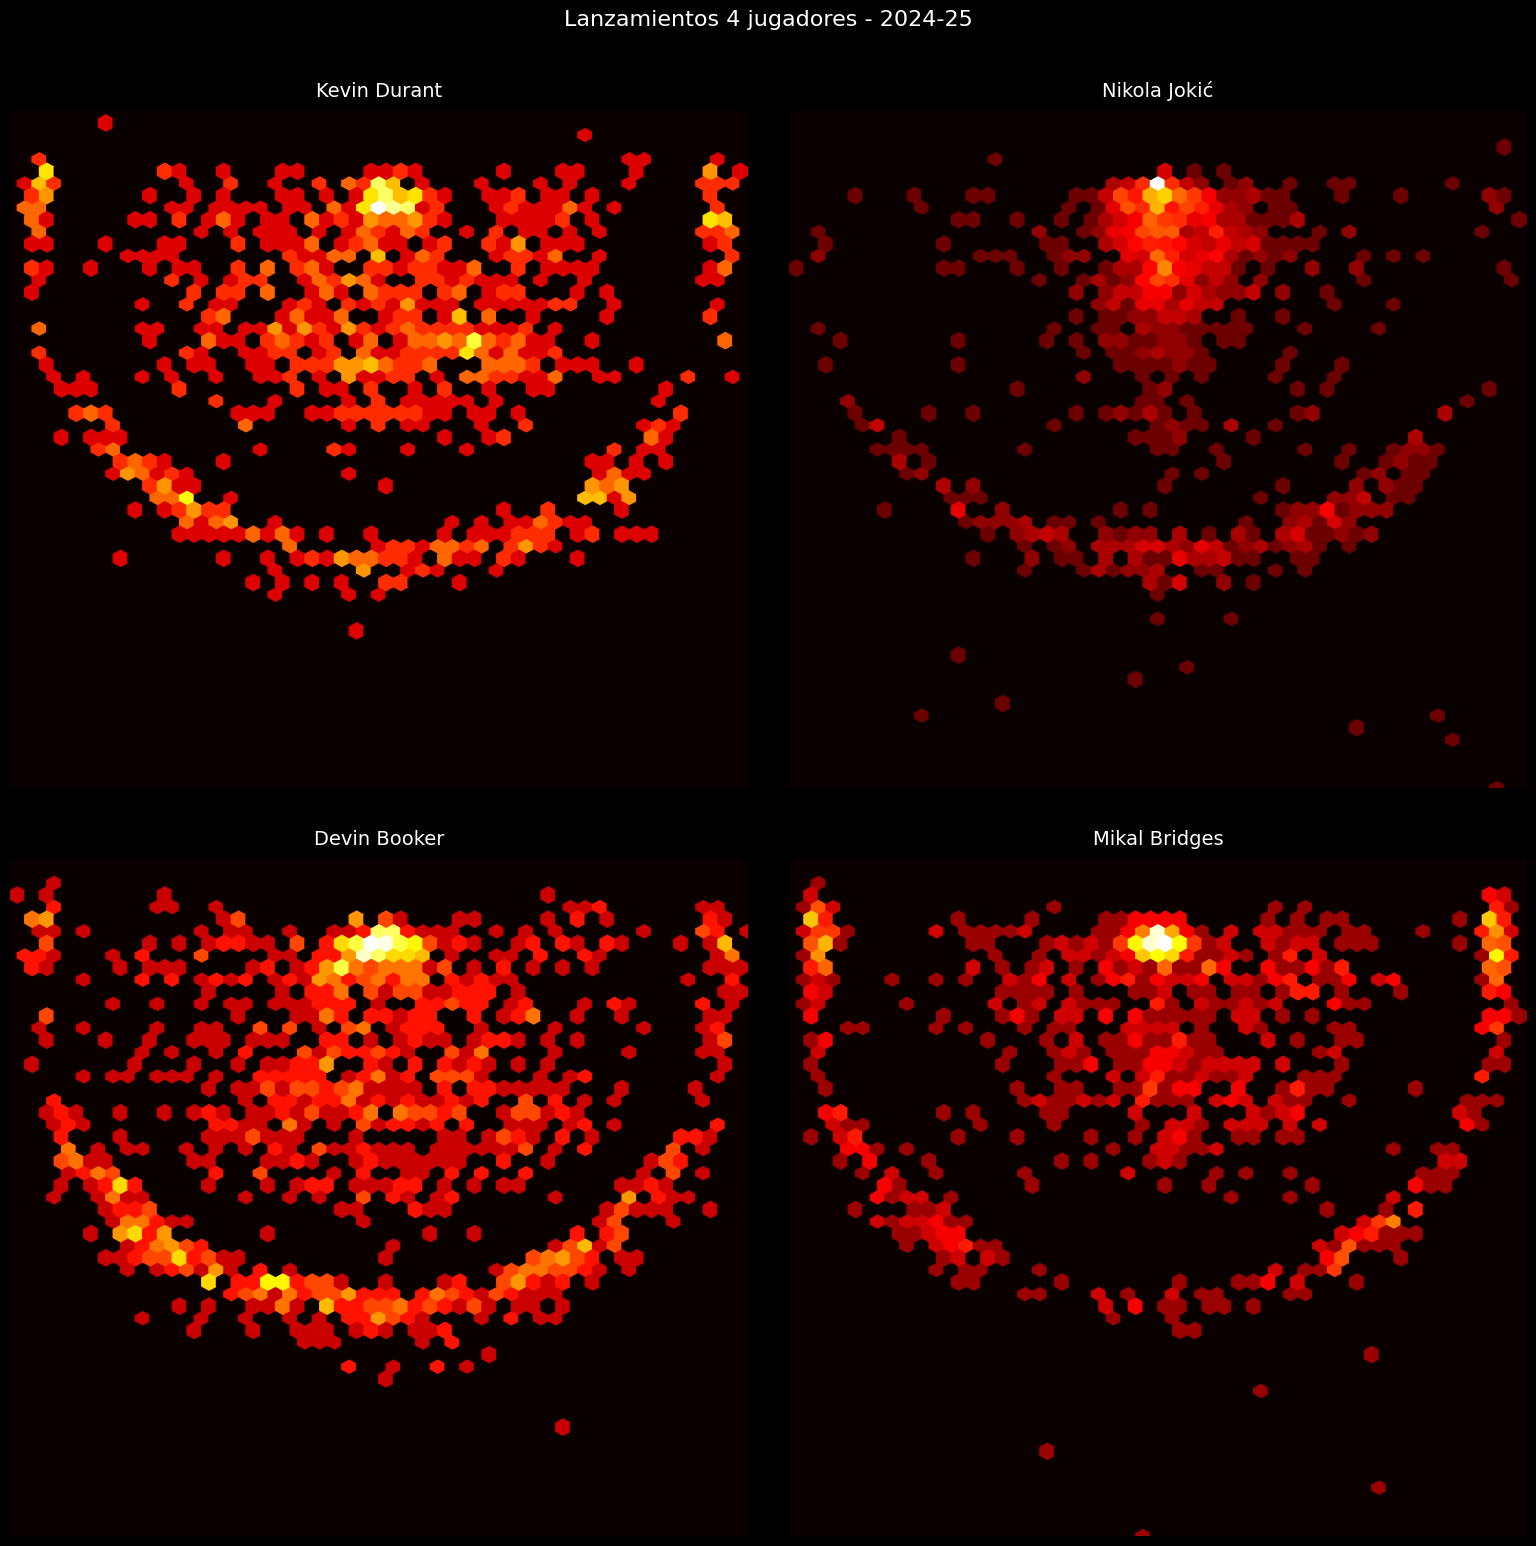

In [6]:
# PRIMERA VISUALIZACIÓN
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# flatten convierte la matriz 2x2 de subplots en una lista de 4
# para poder recorrerlos con un bucle sencillo
axes = axes.flatten()

for i, nombre in enumerate(jugadores.keys()):
    df_jugador = df[df["PLAYER_NAME"] == nombre]
    ax = axes[i]

    hb = ax.hexbin(
        df_jugador["LOC_X"], df_jugador["LOC_Y"],
        gridsize=50,
        cmap="hot",
        mincnt=0,
        norm=mcolors.PowerNorm(gamma=0.45),
        extent=[-250, 250, -50, 420]
    )

    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.invert_yaxis()
    ax.set_facecolor("black")
    ax.set_title(nombre, fontsize=14, pad=10, color="white")
    ax.axis("off")

fig.patch.set_facecolor("black")
plt.suptitle("Lanzamientos 4 jugadores - 2024-25", fontsize=16, color="white")
plt.tight_layout(pad=3.0)
plt.savefig('mapa_calor_top_midrangers.png')
plt.show()

## Primeras conclusiones

Queda claro que Kevin Durant y Devin Booker parecen dos fueras de serie en todo el área.
Nikola Jokic tiene predilección por lanzar bajo el aro respecto a los demás.
Mikal Bridges está a medio camino, pero llama la atención la predilección por los tiros laterales

## Seguimos con el estudio
### ¿Son buenos en todo?
Con esta gráfica nos podemos hacer una buena idea de cómo contestar a esta pregunta, pero vamos a intentar verlo con datos

In [7]:
# Para cada jugador por zona, contamos cuántos lanzamientos intentó y cuántos encestó
# Creo dos columnas nuevas llamadas ATTEMPTS y GOALS
eficiencia = df.groupby(["PLAYER_NAME", "SHOT_ZONE_BASIC"]).agg(
    ATTEMPTS=("SHOT_MADE_FLAG", "count"),
    GOALS=("SHOT_MADE_FLAG", "sum")
).reset_index()

# Sacamos el porcentaje y lo almacenamos en otra columna nueva
eficiencia["EFICIENCIA_%"] = (eficiencia["GOALS"] / eficiencia["ATTEMPTS"] * 100).round(2)

In [8]:
# Lo dicho: por cada zona, todos los cálculos
eficiencia

,PLAYER_NAME,SHOT_ZONE_BASIC,ATTEMPTS,GOALS,EFICIENCIA_%
0,Devin Booker,Above the Break 3,476,157,32.98
1,Devin Booker,In The Paint (Non-RA),342,164,47.95
2,Devin Booker,Left Corner 3,32,11,34.38
3,Devin Booker,Mid-Range,325,168,51.69
4,Devin Booker,Restricted Area,202,139,68.81
5,Devin Booker,Right Corner 3,43,15,34.88
6,Kevin Durant,Above the Break 3,284,116,40.85
7,Kevin Durant,In The Paint (Non-RA),342,182,53.22
8,Kevin Durant,Left Corner 3,42,22,52.38
9,Kevin Durant,Mid-Range,286,152,53.15


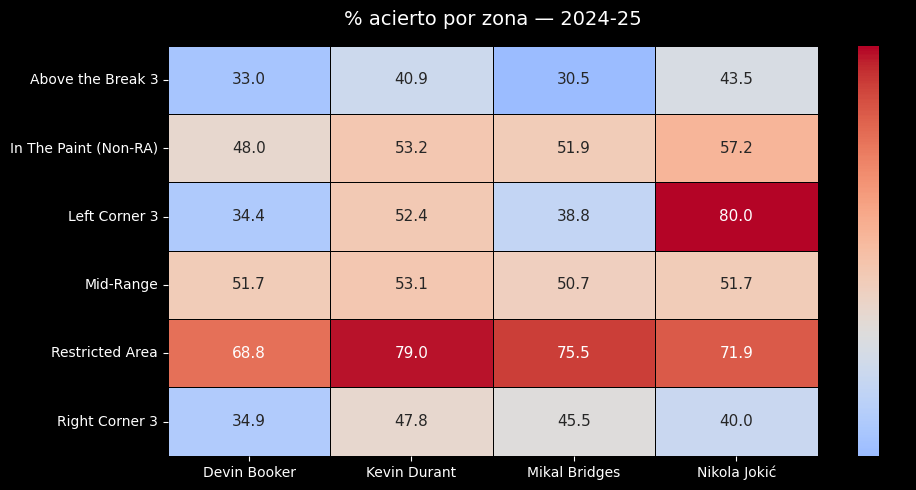

In [9]:
tabla = eficiencia.pivot(index="SHOT_ZONE_BASIC", columns="PLAYER_NAME", values="EFICIENCIA_%")

# Eliminamos Backcourt porque no aporta nada y hace ruido visual
tabla = tabla.drop("Backcourt")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",  # azul = frío/malo, rojo = caliente/bueno
    center=45,
    linewidths=0.5,
    linecolor="black",
    ax=ax,
    annot_kws={"size": 11}
)

ax.set_title("% acierto por zona — 2024-25", fontsize=14, color="white", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(colors="white")
plt.setp(ax.get_xticklabels(), color="white")
plt.setp(ax.get_yticklabels(), color="white", rotation=0)
plt.tight_layout()
plt.savefig("eficiencia_zonas_top4.png", facecolor="black")
plt.show()

Se puede ver claramente lo sobresalientes que son, pero para demostrarlo bien, deberíamos compararlo respecto a la media de jugadores de la NBA.
Es lo que vamos a hacer.

In [10]:
# Nos quedamos otra vez con todos los lanzamientos de la liga

liga = shotchartdetail.ShotChartDetail(
    team_id=0,
    player_id=0,
    context_measure_simple="FGA",
    season_nullable="2024-25",
    season_type_all_star="Regular Season"
)

df_liga = liga.get_data_frames()[0]
df_liga

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0022400001,7,1642258,Zaccharie Risacher,1610612737,Atlanta Hawks,1,11,43,...,Left Side Center(LC),24+ ft.,26,-168,205,1,0,20241112,BOS,ATL
1,Shot Chart Detail,0022400001,10,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,11,38,...,Left Side(L),8-16 ft.,13,-136,-1,1,0,20241112,BOS,ATL
2,Shot Chart Detail,0022400001,12,1628401,Derrick White,1610612738,Boston Celtics,1,11,24,...,Left Side Center(LC),24+ ft.,28,-181,218,1,0,20241112,BOS,ATL
3,Shot Chart Detail,0022400001,21,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,10,50,...,Right Side Center(RC),24+ ft.,25,157,203,1,1,20241112,BOS,ATL
4,Shot Chart Detail,0022400001,23,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,35,...,Right Side Center(RC),24+ ft.,27,102,253,1,1,20241112,BOS,ATL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219522,Shot Chart Detail,0022401230,705,1630578,Alperen Sengun,1610612745,Houston Rockets,4,0,47,...,Center(C),24+ ft.,25,-29,257,1,0,20241214,OKC,HOU
219523,Shot Chart Detail,0022401230,707,1627832,Fred VanVleet,1610612745,Houston Rockets,4,0,42,...,Left Side(L),24+ ft.,22,-228,-17,1,0,20241214,OKC,HOU
219524,Shot Chart Detail,0022401230,715,1629652,Luguentz Dort,1610612760,Oklahoma City Thunder,4,0,24,...,Right Side Center(RC),24+ ft.,24,186,167,1,1,20241214,OKC,HOU
219525,Shot Chart Detail,0022401230,719,1630224,Jalen Green,1610612745,Houston Rockets,4,0,13,...,Center(C),Less Than 8 ft.,2,12,16,1,1,20241214,OKC,HOU


In [11]:
# Calculamos la media por zonas
# Es lo mismo de antes, pero con toda la liga

media_liga = df_liga.groupby("SHOT_ZONE_BASIC").agg(
    ATTEMPTS=("SHOT_MADE_FLAG", "count"),
    GOALS=("SHOT_MADE_FLAG", "sum")
).reset_index()

media_liga["MEDIA_LIGA_%"] = (media_liga["GOALS"] / media_liga["ATTEMPTS"] * 100).round(1)

media_liga[["SHOT_ZONE_BASIC", "MEDIA_LIGA_%"]]

,SHOT_ZONE_BASIC,MEDIA_LIGA_%
0,Above the Break 3,35.3
1,Backcourt,2.3
2,In The Paint (Non-RA),44.4
3,Left Corner 3,38.6
4,Mid-Range,41.7
5,Restricted Area,66.4
6,Right Corner 3,39.0


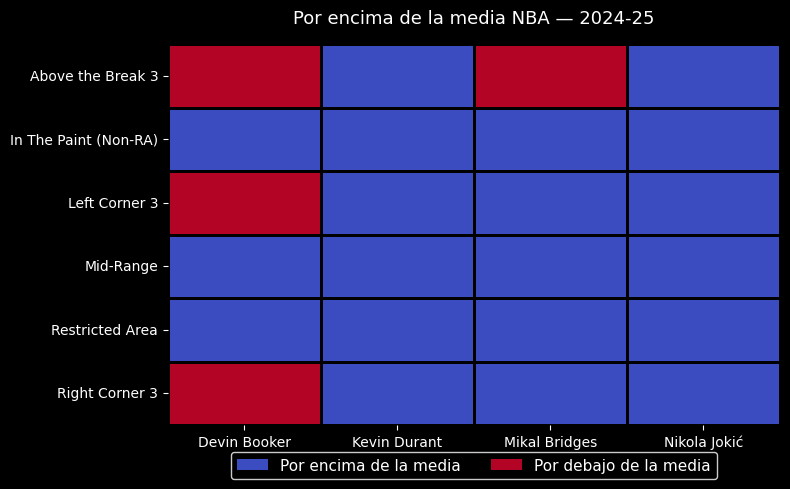

In [12]:
# VISUALIZACIÓN
# Hacemos un heatmap de seaborn para mostrar si están o no por encima de la media por cada zona
# Para hacerlo visualmente interesante, hubo que crear una tabla de booleanos para indicar si estaba por encima o por debajo de la media cada jugador
# 


from matplotlib.patches import Patch

# Diccionario con la media de la liga por zonas
media_dict = media_liga.set_index("SHOT_ZONE_BASIC")["MEDIA_LIGA_%"].to_dict()

# Guardamos solo las zonas que queremos. Backcourt no sirve para nada
zonas_validas = ["Above the Break 3", "In The Paint (Non-RA)", "Left Corner 3", 
                 "Mid-Range", "Restricted Area", "Right Corner 3"]

tabla_bool = pd.DataFrame(index=zonas_validas, columns=["Devin Booker", "Kevin Durant", "Mikal Bridges", "Nikola Jokić"])

for zona in zonas_validas:
    for jugador in tabla_bool.columns:
        tabla_bool.loc[zona, jugador] = tabla.loc[zona, jugador] > media_dict[zona]

tabla_bool = tabla_bool.astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sns.heatmap(
    tabla_bool,
    cmap="coolwarm_r",
    center=0.5,
    linewidths=1,
    linecolor="black",
    cbar=False,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_title("Por encima de la media NBA — 2024-25", fontsize=13, color="white", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(colors="white")
plt.setp(ax.get_xticklabels(), color="white")
plt.setp(ax.get_yticklabels(), color="white", rotation=0)
leyenda = [
    Patch(facecolor="#3b4cc0", label="Por encima de la media"),
    Patch(facecolor="#b40426", label="Por debajo de la media")
]
ax.legend(handles=leyenda, loc="upper center", frameon=True,
          facecolor="black", edgecolor="white",
          labelcolor="white", fontsize=11,
          bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.savefig("supera_media_liga.png")
plt.show()

Salvo Devin Booker, el resto cumple con parecer jugadores de élite. Están por encima de la media, pero
¿Estarán por encima de un 80%?

In [13]:
# Filtramos jugadores con mínimo de intentos para que no salgan jugadores con 1 tiro y 100%
# Ya habíamos calculado y acordado estos 400 lanzamientos
MIN_INTENTOS = 400

eficiencia_liga = df_liga.groupby(["PLAYER_NAME", "SHOT_ZONE_BASIC"]).agg(
    ATTEMPTS=("SHOT_MADE_FLAG", "count"),
    GOALS=("SHOT_MADE_FLAG", "sum")
).reset_index()

eficiencia_liga["EFICIENCIA_%"] = (eficiencia_liga["GOALS"] / eficiencia_liga["ATTEMPTS"] * 100).round(1)

# Nos quedamos solo con jugadores que hayan tirado suficiente desde esa zona
eficiencia_liga = eficiencia_liga[eficiencia_liga["ATTEMPTS"] >= MIN_INTENTOS]

eficiencia_liga

,PLAYER_NAME,SHOT_ZONE_BASIC,ATTEMPTS,GOALS,EFICIENCIA_%
114,Alperen Sengun,In The Paint (Non-RA),466,194,41.6
117,Alperen Sengun,Restricted Area,481,312,64.9
158,Anfernee Simons,Above the Break 3,529,194,36.7
178,Anthony Edwards,Above the Break 3,701,277,39.5
216,Austin Reaves,Above the Break 3,455,168,36.9
230,Bam Adebayo,In The Paint (Non-RA),444,192,43.2
400,Buddy Hield,Above the Break 3,413,151,36.6
415,Cade Cunningham,In The Paint (Non-RA),483,241,49.9
524,Christian Braun,Restricted Area,428,306,71.5
539,Coby White,Above the Break 3,495,185,37.4


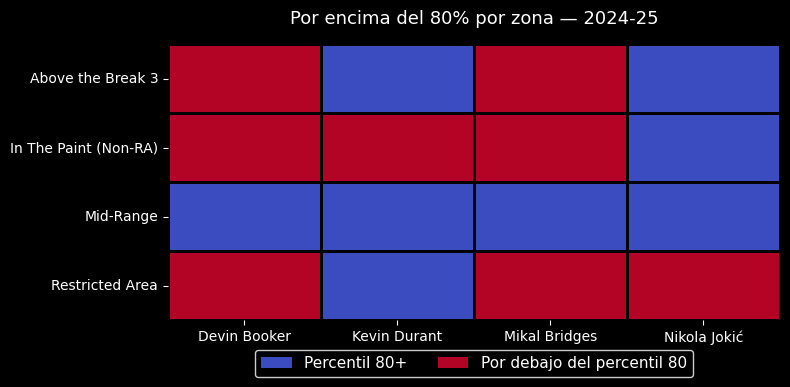

In [18]:
jugadores_lista = ["Devin Booker", "Kevin Durant", "Mikal Bridges", "Nikola Jokić"]
zonas_con_datos = ["Above the Break 3", "In The Paint (Non-RA)", "Mid-Range", "Restricted Area"]

# Creamos tabla de percentiles
tabla_percentil = pd.DataFrame(index=zonas_con_datos, columns=jugadores_lista)

for zona in zonas_con_datos:
    valores_zona = eficiencia_liga[eficiencia_liga["SHOT_ZONE_BASIC"] == zona]["EFICIENCIA_%"].tolist()
    for jugador in jugadores_lista:
        val = tabla.loc[zona, jugador]
        percentil = len([v for v in valores_zona if v < val]) / len(valores_zona) * 100
        tabla_percentil.loc[zona, jugador] = percentil

# Booleano: por encima del percentil 80 o no
tabla_p80 = (tabla_percentil.astype(float) >= 80).astype(int)

# Heatmap
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

sns.heatmap(
    tabla_p80,
    cmap="coolwarm_r",
    center=0.5,
    linewidths=1,
    linecolor="black",
    cbar=False,
    ax=ax,
    annot_kws={"size": 16}
)

leyenda = [
    Patch(facecolor="#3b4cc0", label="Percentil 80+"),
    Patch(facecolor="#b40426", label="Por debajo del percentil 80")
]
ax.legend(handles=leyenda, loc="upper center", frameon=True,
          facecolor="black", edgecolor="white",
          labelcolor="white", fontsize=11,
          bbox_to_anchor=(0.5, -0.08), ncol=2)

ax.set_title("Por encima del 80% por zona — 2024-25", fontsize=13, color="white", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(colors="white")
plt.setp(ax.get_xticklabels(), color="white")
plt.setp(ax.get_yticklabels(), color="white", rotation=0)
plt.tight_layout()
plt.savefig("percentil80_zonas.png")
plt.show()

## CONCLUSIONES
**Booker:** No tan élite como esperábamos, aunque destaque en mid-range a pesar de la tendencia.  
**Durant:** Un fuera de serie, un auténtico dominio de todas las zonas.  
**Bridges:** Le ocurre como a Booker, aunque gracias a las otras gráficas sabemos que es algo más eficiente.  
**Jokic:** Otro fuera de serie, aunque con una clara tendencia a encestar bajo el aro  